# Model B – Model Training & Selection

**Goal:** Train several classical machine learning classifiers on the
pre‑computed Word2Vec document vectors and select the best‑performing one
for phishing detection then save it into `models\best_model_b.joblib`.

**Input:**  
The file `data/processed/word2vec_features.csv`, which contains:
- 150 numerical features (averaged Word2Vec dimensions)
- A binary `label` column (0 = legitimate, 1 = phishing)

**Approach:**
- Load the feature matrix and labels.
- Train and evaluate multiple models using stratified 5‑fold cross‑validation.
- Compare their **F1 scores** (the harmonic mean of precision and recall),
  as phishing detection often involves imbalanced classes.
- Pick the best model and save it for future inference.

**Candidate models (all lightweight, no GPU required):**
- Logistic Regression
- Random Forest
- Naive Bayes

At the end of this notebook we will have a **trained, saved model** ready to
deploy on new email text.

## 1. Load and Split the Data
We load the numerical vectors from `word2vec_features.csv` and partition
them into **train (60%)**, **validation (20%)**, and **test (20%)**.

Stratification ensures each set maintains the same proportion of
phishing/legitimate emails as the original dataset — critical for
imbalanced data.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
features_path = PROJECT_ROOT / "data" / "model_b" / "vectorized_data" / "word2vec_features.csv"
df = pd.read_csv(features_path)

X = df.drop(columns=["label"]).values
y = df["label"].values

print(f"Full dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Label distribution:\n{pd.Series(y).value_counts().sort_index()}")

# Split off 40% for validation+test, then split that evenly → 20% each
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nTrain: {X_train.shape[0]}  |  label counts: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Val:   {X_val.shape[0]}  |  label counts: {pd.Series(y_val).value_counts().to_dict()}")
print(f"Test:  {X_test.shape[0]}  |  label counts: {pd.Series(y_test).value_counts().to_dict()}")

Full dataset: 164467 samples, 150 features
Label distribution:
0    78821
1    85646
Name: count, dtype: int64

Train: 98680  |  label counts: {1: 51387, 0: 47293}
Val:   32893  |  label counts: {1: 17129, 0: 15764}
Test:  32894  |  label counts: {1: 17130, 0: 15764}


The following code cell will `save splits to disk` to use them for several models. To ensure fairness between models.

In [3]:
output_dir = PROJECT_ROOT / "data" / "model_b" /"splits"
output_dir.mkdir(parents=True, exist_ok=True)
for split_name, (X_split, y_split) in zip(
    ["train", "val", "test"],
    [(X_train, y_train), (X_val, y_val), (X_test, y_test)]
):
    split_df = pd.DataFrame(X_split, columns=[f"dim_{i}" for i in range(X_split.shape[1])])
    split_df["label"] = y_split
    split_df.to_csv(output_dir / f"word2vec_{split_name}.csv", index=False)
    print(f"Saved {split_name}.csv")

Saved train.csv
Saved val.csv
Saved test.csv


## 2) Models Training and Evaluation
We will train `3 models` and evaluate each one by using the `evaluation set` to decide whether we move to the next model or changing the parmeters of the model then train again.
### 2.1. Model 1 – Random Forest
A Random Forest classifier is an ensemble of decision trees that often
works well with dense numerical features like averaged word embeddings.

We’ll train on the **training set**, evaluate on the **validation set**,
and report:
- F1 score (main metric for this project)
- Precision & Recall
- Confusion matrix

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Validate
y_val_pred = rf.predict(X_val)

f1 = f1_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)

print("Random Forest – Validation Performance")
print(f"F1 Score:     {f1:.4f}")
print(f"Precision:    {prec:.4f}")
print(f"Recall:       {rec:.4f}")
print(f"Confusion Matrix:\n{cm}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Phishing"]))

Random Forest – Validation Performance
F1 Score:     0.9882
Precision:    0.9880
Recall:       0.9884
Confusion Matrix:
[[15559   205]
 [  199 16930]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     15764
    Phishing       0.99      0.99      0.99     17129

    accuracy                           0.99     32893
   macro avg       0.99      0.99      0.99     32893
weighted avg       0.99      0.99      0.99     32893



### 2.2. Model 2 – Logistic Regression
Logistic Regression is a linear model that works well with averaged word
embeddings. It serves as a quick, interpretable baseline.

We use the same training/validation split and report the same metrics.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_val_pred = lr.predict(X_val)

f1 = f1_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)

print("Logistic Regression – Validation Performance")
print(f"F1 Score:     {f1:.4f}")
print(f"Precision:    {prec:.4f}")
print(f"Recall:       {rec:.4f}")
print(f"Confusion Matrix:\n{cm}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Phishing"]))

Logistic Regression – Validation Performance
F1 Score:     0.9720
Precision:    0.9703
Recall:       0.9738
Confusion Matrix:
[[15253   511]
 [  449 16680]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97     15764
    Phishing       0.97      0.97      0.97     17129

    accuracy                           0.97     32893
   macro avg       0.97      0.97      0.97     32893
weighted avg       0.97      0.97      0.97     32893



## 2.3. Model 3 – Gaussian Naive Bayes (fast & simple)
It assumes features are normally distributed – a reasonable approximation
for averaged word vectors – and it trains almost instantly.

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Train
nb = GaussianNB()
nb.fit(X_train, y_train)

# Validate
y_val_pred = nb.predict(X_val)

f1 = f1_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)

print("Gaussian Naive Bayes – Validation Performance")
print(f"F1 Score:     {f1:.4f}")
print(f"Precision:    {prec:.4f}")
print(f"Recall:       {rec:.4f}")
print(f"Confusion Matrix:\n{cm}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate", "Phishing"]))

Gaussian Naive Bayes – Validation Performance
F1 Score:     0.7847
Precision:    0.9004
Recall:       0.6954
Confusion Matrix:
[[14446  1318]
 [ 5218 11911]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.73      0.92      0.82     15764
    Phishing       0.90      0.70      0.78     17129

    accuracy                           0.80     32893
   macro avg       0.82      0.81      0.80     32893
weighted avg       0.82      0.80      0.80     32893



## 3) Model Selection

We now use the **test set** (unseen during training & validation) to measure
true generalization performance. For each model we:

- Predict labels on `X_test`
- Compute F1, precision, recall
- Plot a confusion matrix

So, The Final Evaluation will be on the Test Set.

Finally, we pick the best model according to **F1 score** and announce it.

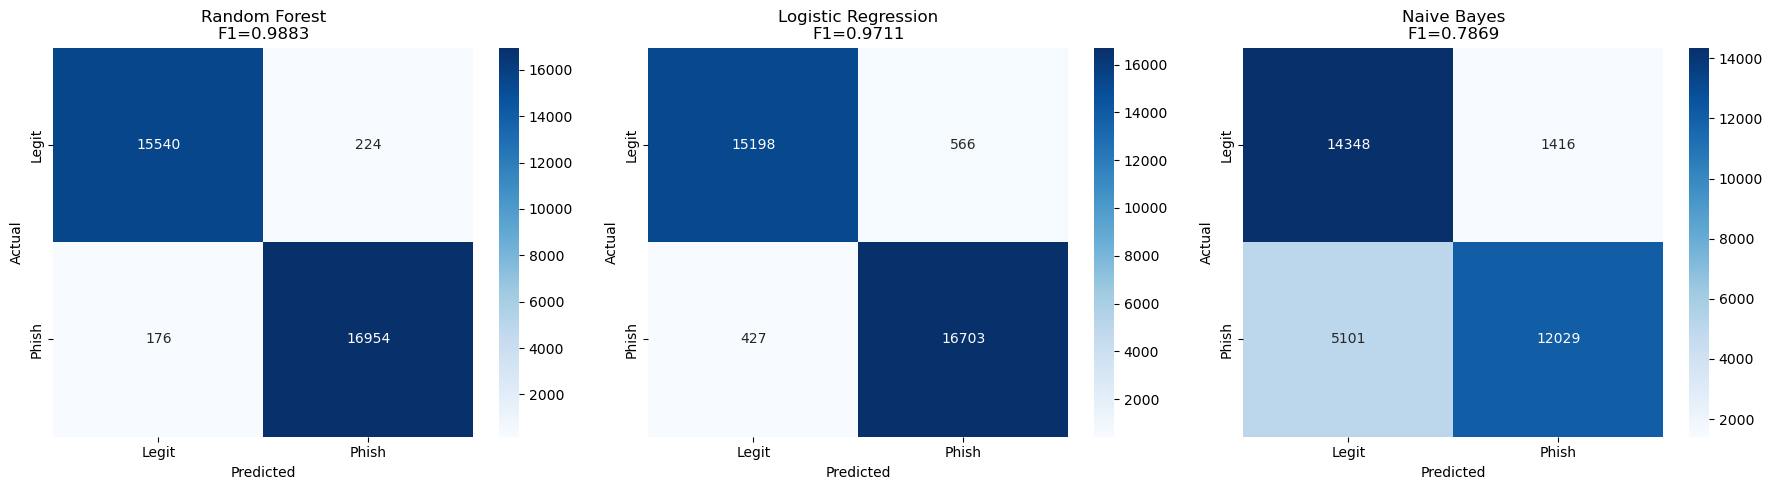


Test Set Performance Summary:
                         F1  Precision  Recall
Random Forest        0.9883     0.9870  0.9897
Logistic Regression  0.9711     0.9672  0.9751
Naive Bayes          0.7869     0.8947  0.7022

Best model based on F1 score: **Random Forest** (F1 = 0.9883)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

models = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "Naive Bayes": nb,
}

results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {"F1": f1, "Precision": prec, "Recall": rec}
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Legit", "Phish"],
                yticklabels=["Legit", "Phish"],
                ax=axes[i])
    axes[i].set_title(f"{name}\nF1={f1:.4f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Print summary table
print("\nTest Set Performance Summary:")
summary_df = pd.DataFrame(results).T
print(summary_df.round(4))

# Determine the best model
best_model = max(results, key=lambda x: results[x]["F1"])
print(f"\nBest model based on F1 score: **{best_model}** (F1 = {results[best_model]['F1']:.4f})")

## 4) Save the Best Model
We save the winner (`best_model`) into the `models/` folder as
`best_model_b.joblib`. This file can be loaded directly in a deployment
notebook with `joblib.load()`.

In [8]:
import joblib
from pathlib import Path

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / "best_model_b.joblib"
joblib.dump(models[best_model], best_model_path)

print(f"Best model ('{best_model}') saved to: {best_model_path}")

Best model ('Random Forest') saved to: C:\Work\current\phishing_detection\models\best_model_b.joblib
